# XAS Prediction using simple Graph Neural Networks

###  GNN project done in Berlin at HZB with the tutoring
### of Hendrik Junkawitsch and Sandeep kumar.

In [ ]:
from google.colab import drive
#drive.mount('/content/drive')
drive.mount("/content/drive", force_remount=True)
folder_path = '/content/drive/My Drive/Hendrick'

Mounted at /content/drive


In [ ]:
# # Install missing packages in Colab
# Install a clean compatible version of NumPy
#!pip install numpy==1.26.4 --force-reinstall
!pip install numpy==1.26.4

# Install the correct versions of PyTorch and PyTorch Geometric
# !pip install torch==2.6.0 torchvision torchaudio
# !pip install -q torch-scatter -f https://data.pyg.org/whl/torch-2.6.0+cu124.html
# !pip install -q torch-sparse -f https://data.pyg.org/whl/torch-2.6.0+cu124.html
!pip install -q torch-cluster -f https://data.pyg.org/whl/torch-2.6.0+cu124.html
#!pip install -q torch-geometric
!pip install -q torch-geometric==2.3.0

# Install additional packages
!pip install rdkit-pypi py3Dmol ase matplotlib

# Import necessary libraries
# --- Import necessary libraries ---
import random
import pickle
import numpy as np
import torch
import torch.nn.functional as F
import torch_geometric as tgeo
from pprint import pprint
from rdkit import Chem
import py3Dmol
import matplotlib.pyplot as plt
from collections import Counter
import networkx as nx
import pandas as pd
import ase
import torch_geometric
from torch_geometric.nn import radius_graph

# Set global figure settings for plotting
plt.rcParams["figure.figsize"] = (15, 5)
plt.rcParams["figure.dpi"] = 100

# Set random seed for reproducibility
seed = 42  # You can choose any integer seed value
random.seed(seed)  # Python random
np.random.seed(seed)  # NumPy random
torch.manual_seed(seed)  # PyTorch seed
torch.cuda.manual_seed(seed)  # If using GPU
torch.cuda.manual_seed_all(seed)  # If using multi-GPU
torch.backends.cudnn.deterministic = True  # Ensures deterministic algorithms
torch.backends.cudnn.benchmark = False  # Disables the automatic optimization of algorithms

# Check versions to confirm compatibility
import os
print("PyTorch version:", torch.__version__)
print("NumPy version:", np.__version__)



PyTorch version: 2.6.0+cu124
NumPy version: 1.26.4


In [ ]:
# Utility function
def print_table(data, columns):
    df = pd.DataFrame(data, columns=columns)
    pd.set_option("display.max_colwidth", 5)  # Adjust as needed (in characters)
    display(df)

## 1. Loading the raw QM9_XAS data

We first load the raw and unknown dataset using the Python package **Pickle**. Furthermore, we
- take a **random subset** of the whole training data for this tutorial,
- check the **type** of the data,
- and can finally print our **dataset size**.

<br>
<br>

> *Pickle files store serialized Python objects in a binary format. Pickle files (or similar) are commonly used to save machine learning models, datasets, or any other Python objects that need to be saved between sessions. In the context of this tutorial, we'll use data that is already in a somewhat nice format.*

In [ ]:
dataset_path = "/content/drive/My Drive/Hendrick/data/data_new.pkl"

with open(dataset_path, "rb") as f:
    data = pickle.load(f)

# data = random.sample(data, 5000)  # taking a random subset of the data
data = data[:3000]

print(f"Dataset Python type: {type(data)}")
print(f"Dataset size: {len(data)}")

Dataset Python type: <class 'list'>
Dataset size: 3000


## 2. What exactly is in this ominous Pickle file?

### 2.1 Simple print

We now want to find out how each entry of our dataset looks like and what it represents.

We can simply print a single entry of the Python list to see its contents:

In [ ]:
print("Example data point:")
pprint(data[0])

Example data point:
{'atoms': ['O',
           'C',
           'N',
           'C',
           'C',
           'C',
           'O',
           'C',
           'O',
           'H',
           'H',
           'H',
           'H',
           'H',
           'H',
           'H'],
 'coordinates': array([[ 3.81697497e-01,  6.68031903e-01,  1.09972305e+00],
       [ 2.00687641e-01,  1.41955581e+00,  1.62806157e-01],
       [ 1.11105687e+00,  1.65928516e+00, -8.18144557e-01],
       [ 2.44423649e+00,  1.09644656e+00, -7.58069391e-01],
       [ 3.41824510e+00,  1.95296515e+00,  8.34758313e-02],
       [ 4.72166163e+00,  1.21353987e+00,  3.41360809e-01],
       [ 5.80814039e+00,  1.61812409e+00,  1.66647810e-02],
       [ 3.66941982e+00,  3.32154584e+00, -5.26148003e-01],
       [ 3.07458006e+00,  3.74025556e+00, -1.48869930e+00],
       [-7.41497561e-01,  1.97852177e+00,  4.65651750e-03],
       [ 9.66149006e-01,  2.42799548e+00, -1.45428836e+00],
       [ 2.36199999e+00,  1.01244855e-01, -3.14

### 2.2 2D Visualization

It seems like the data contains atoms `'atoms'` with its corresponding positions `'coordinates'`, an ID `'id'`, a SMILES string `'smiles'`, and an absorption spectrum `'spectrum'`.

The simplest way for us to visualize the molecule is by directly using the **SMILES** string: `'smiles'`.

> *A SMILES string is a text-based representation of a molecule's structure. It uses letters for atoms and symbols for bonds, encoding molecular connectivity. For example, "C1CCCCC1" represents cyclohexane, a six-membered carbon ring.*

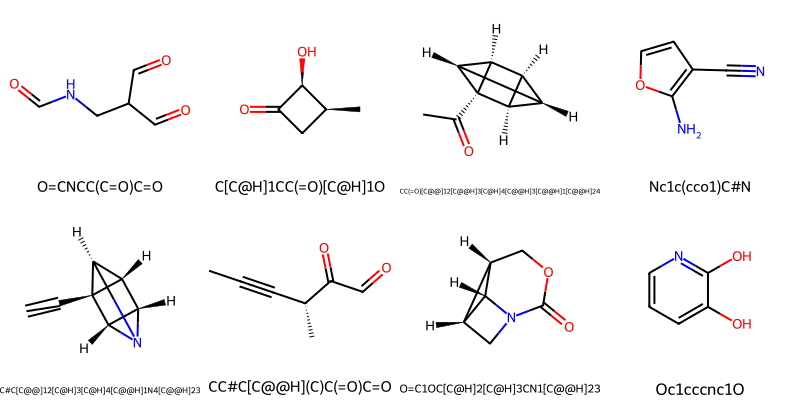

In [ ]:
# samples = random.sample(data, 8)  # generate 6 random samples
samples = data[:8]

# Convert SMILES strings to RDKit molecule objects
rdkit_molecules = [Chem.MolFromSmiles(m["smiles"]) for m in samples]

img = Chem.Draw.MolsToGridImage(
    rdkit_molecules, molsPerRow=4, subImgSize=(200, 200), legends=[m["smiles"] for m in samples]
)
img

### 2.4 Spectra Visualization

Last but not least we can visualize the absorption spectrum `'spectrum'` for each of our eight sample molecules in a 2D plot.

> *X-ray absorption spectroscopy (XAS) is a powerful experimental technique that provides insight into the electronic structure and local environment of atoms in a material. The XAS is measured by observing the absorption of X-rays (y-axis) as their energy is tuned over a range (x-axis). The resulting spectra contain information about the bonding, oxidation state, coordination, and other structural details of the atoms being probed. There are two main regions of XAS: the X-ray Absorption Near Edge Structure (XANES) and the Extended X-ray Absorption Fine Structure (EXAFS).*

> *In this tutorial, the XAS were theoretically computed using Density Functional Theory (DFT) and Time-Dependent Density Functional Theory (TDDFT). We employed ORCA, a quantum chemistry software, to perform these calculations, which allowed us to predict the XAS by simulating the interaction between the material and X-ray photons.*

In [ ]:
# Plotting Function
def plot_8_arrays(arrays, title, x_label, y_label, subplot_titles):
    fig, axes = plt.subplots(2, 4, figsize=(12, 6))
    axes = axes.flatten()
    fig.suptitle(title, fontsize=16)
    for i, ax in enumerate(axes):
        ax.plot(arrays[i])
        if subplot_titles:
            ax.set_title(subplot_titles[i] if i < len(subplot_titles) else f"Plot {i+1}", fontsize=10)
        else:
            ax.set_title(f"Plot {i+1}")
        ax.set_xlabel(x_label)
        ax.set_ylabel(y_label)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

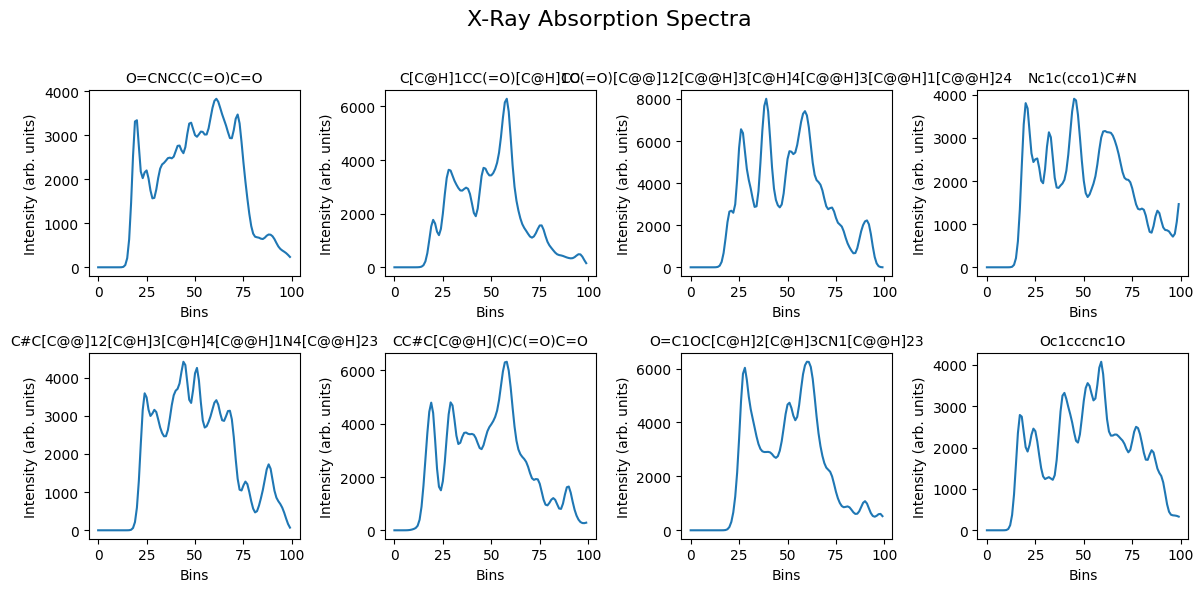

In [ ]:
sample_spectra = [m["spectrum"] for m in samples]
plot_8_arrays(
    sample_spectra,
    title="X-Ray Absorption Spectra",
    x_label="Bins",
    y_label="Intensity (arb. units)",
    subplot_titles=[m["smiles"] for m in samples],
)

## 3. Data analysis

Now that we know what each data point looks like we can run a more extensive analysis of our dataset.

We can visualize:
- Number of atoms
- Number of carbon atoms
- Number of hydrogen atoms
- Number of heavy atoms
- Total number of different elements in the data
- 3D coordinate distribution

In [ ]:
# Plotting Function
def plot_bar(y, x=None, title="Bar Plot", xlabel="Index", ylabel="Value"):
    y = np.array(y)
    if x is None:
        x = np.arange(len(y))
    else:
        x = np.array(x)

    bars = plt.bar(x, y, color="gray", edgecolor="black")

    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width() / 2, height, f"{height}", ha="center", va="bottom", fontsize=10)

    plt.xticks(x, labels=x, rotation=0)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.grid(axis="y", linestyle="--", alpha=0.7)
    plt.show()

In [ ]:
# Utility Function
def compute_distribution(data):
    data = np.array(data)
    unique_values, counts = np.unique(data, return_counts=True)

    if np.issubdtype(data.dtype, np.integer):
        full_range = np.arange(unique_values.min(), unique_values.max() + 1)
        full_counts = np.zeros_like(full_range)

        value_to_count = dict(zip(unique_values, counts))
        full_counts = np.array([value_to_count.get(x, 0) for x in full_range])

        return full_range, full_counts

    return unique_values, counts

In [ ]:
# Utility Function
def compute_distribution_2d(data):
    flat_list = [item for sublist in data for item in sublist]

    counter = Counter(flat_list)
    unique_values = np.array(list(counter.keys()))
    counts = np.array(list(counter.values()))

    if all(isinstance(x, int) for x in unique_values):
        full_range = np.arange(unique_values.min(), unique_values.max() + 1)
        full_counts = np.array([counter.get(x, 0) for x in full_range])
        return full_range, full_counts

    return unique_values, counts

In [ ]:
atoms = []
num_atoms = []
no_C_idxs = []
num_C_atoms = []
num_H_atoms = []
num_heavy_atoms = []
for i, d in enumerate(data):
    atoms.append(d["atoms"])
    if "C" not in d["atoms"]:
        no_C_idxs.append(i)
    num_atoms.append(len(d["atoms"]))
    num_C = d["atoms"].count("C")
    num_C_atoms.append(num_C)
    num_H = d["atoms"].count("H")
    num_H_atoms.append(num_H)
    num_heavy_atoms.append(len(d["atoms"]) - num_H)

num_atoms = np.asarray(num_atoms)
no_C_idxs = np.asarray(no_C_idxs)
num_C_atoms = np.asarray(num_C_atoms)
num_H_atoms = np.asarray(num_H_atoms)
num_heavy_atoms = np.asarray(num_heavy_atoms)

print(f"Number of molecules: {len(num_atoms)}")

Number of molecules: 3000


### 3.1 Number of atoms


Average  number of atoms: 16.647333333333332
Maximum  number of atoms: 26
Minimum  number of atoms: 6


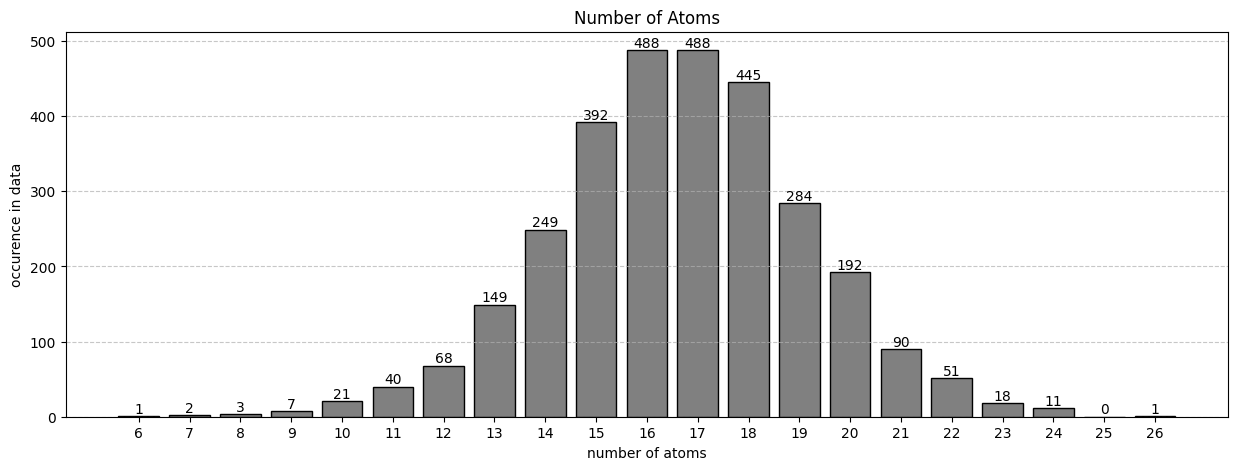

In [ ]:
print(f"Average  number of atoms: {np.mean(num_atoms)}")
print(f"Maximum  number of atoms: {np.max(num_atoms)}")
print(f"Minimum  number of atoms: {np.min(num_atoms)}")
num_atoms_distr_x, num_atoms_distr_y = compute_distribution(num_atoms)
plot_bar(
    num_atoms_distr_y, num_atoms_distr_x, title="Number of Atoms", xlabel="number of atoms", ylabel="occurence in data"
)

### 3.2 Number of carbon atoms

The number of carbon atoms is important because the computed XAS corresponds to the **carbon K-edge** absorption spectra. This means that each molecule in our data contains at least **one** carbon atom, which is responsible for absorbing the X-ray energy at the carbon K-edge. If the molecule consists of multiple carbon atoms, the resulting absorption spectrum is the 'average'/'sum' of the **site-specfic** spectra.

Average  number of carbon atoms: 6.049333333333333
Maximum number of carbon atoms: 9
Minimum number of carbon atoms: 1
Number of molecules without carbon: 0


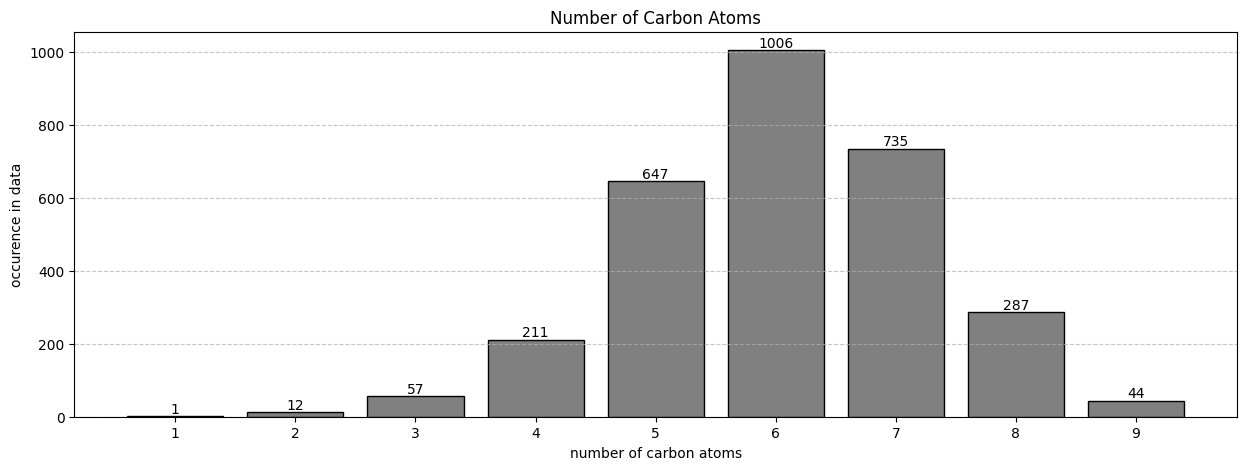

In [ ]:
print(f"Average  number of carbon atoms: {np.mean(num_C_atoms)}")
print(f"Maximum number of carbon atoms: {np.max(num_C_atoms)}")
print(f"Minimum number of carbon atoms: {np.min(num_C_atoms)}")
print(f"Number of molecules without carbon: {len(no_C_idxs)}")
num_C_distr_x, num_C_distr_y = compute_distribution(num_C_atoms)
plot_bar(
    num_C_distr_y,
    num_C_distr_x,
    title="Number of Carbon Atoms",
    xlabel="number of carbon atoms",
    ylabel="occurence in data",
)

### 3.3 Number of hydrogen atoms

Average  number of hydrogen atoms: 8.140666666666666
Maximum number of hydrogen atoms: 18
Minimum number of hydrogen atoms: 0


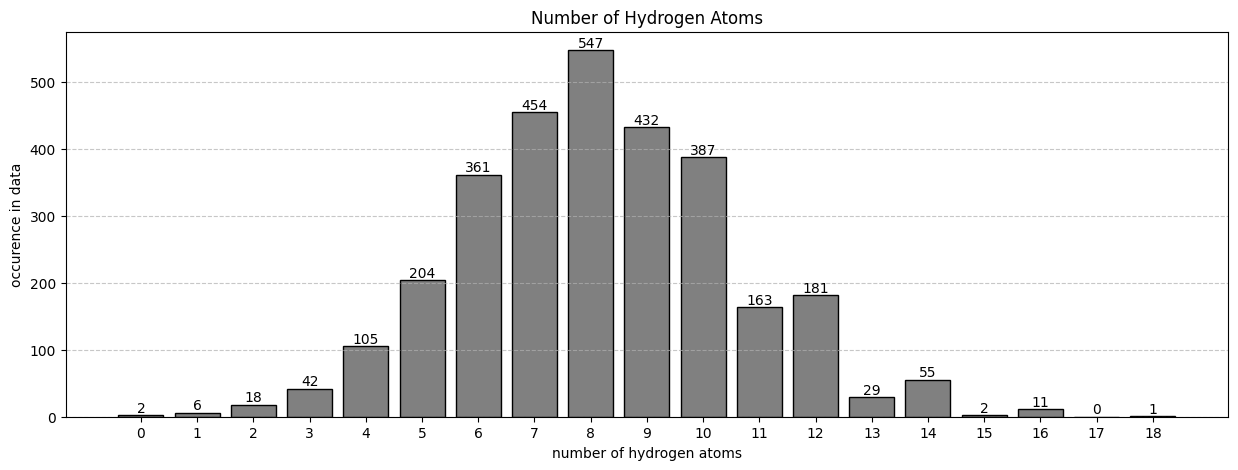

In [ ]:
print(f"Average  number of hydrogen atoms: {np.mean(num_H_atoms)}")
print(f"Maximum number of hydrogen atoms: {np.max(num_H_atoms)}")
print(f"Minimum number of hydrogen atoms: {np.min(num_H_atoms)}")
num_H_distr_x, num_H_distr_y = compute_distribution(num_H_atoms)
plot_bar(
    num_H_distr_y,
    num_H_distr_x,
    title="Number of Hydrogen Atoms",
    xlabel="number of hydrogen atoms",
    ylabel="occurence in data",
)

### 3.4 Number of heavy atoms

Average  number of hydrogen atoms: 8.506666666666666
Maximum number of hydrogen atoms: 9
Minimum number of hydrogen atoms: 4


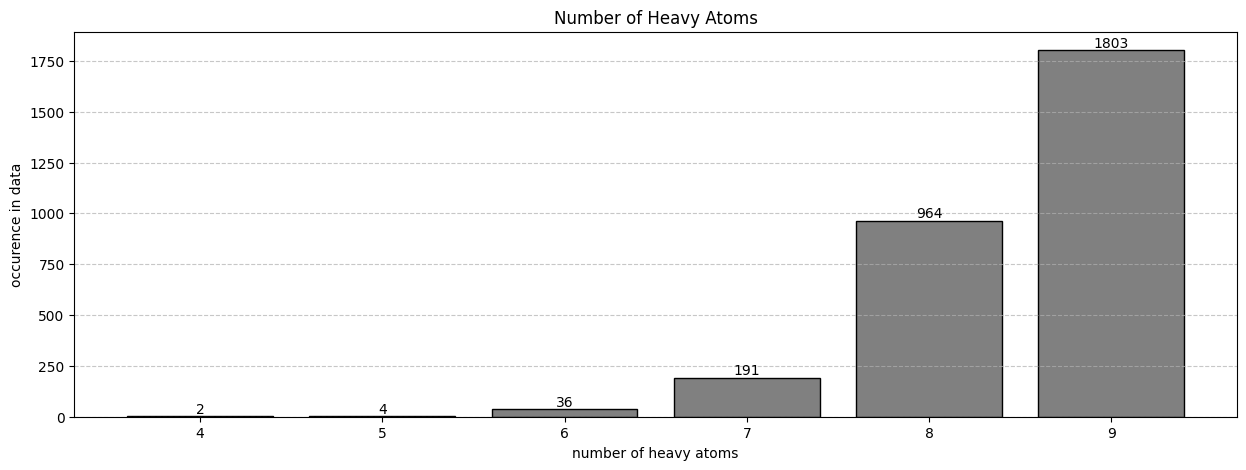

In [ ]:
print(f"Average  number of hydrogen atoms: {np.mean(num_heavy_atoms)}")
print(f"Maximum number of hydrogen atoms: {np.max(num_heavy_atoms)}")
print(f"Minimum number of hydrogen atoms: {np.min(num_heavy_atoms)}")
num_heavy_distr_x, num_heavy_distr_y = compute_distribution(num_heavy_atoms)
plot_bar(
    num_heavy_distr_y,
    num_heavy_distr_x,
    title="Number of Heavy Atoms",
    xlabel="number of heavy atoms",
    ylabel="occurence in data",
)

### 3.5 Number of elements

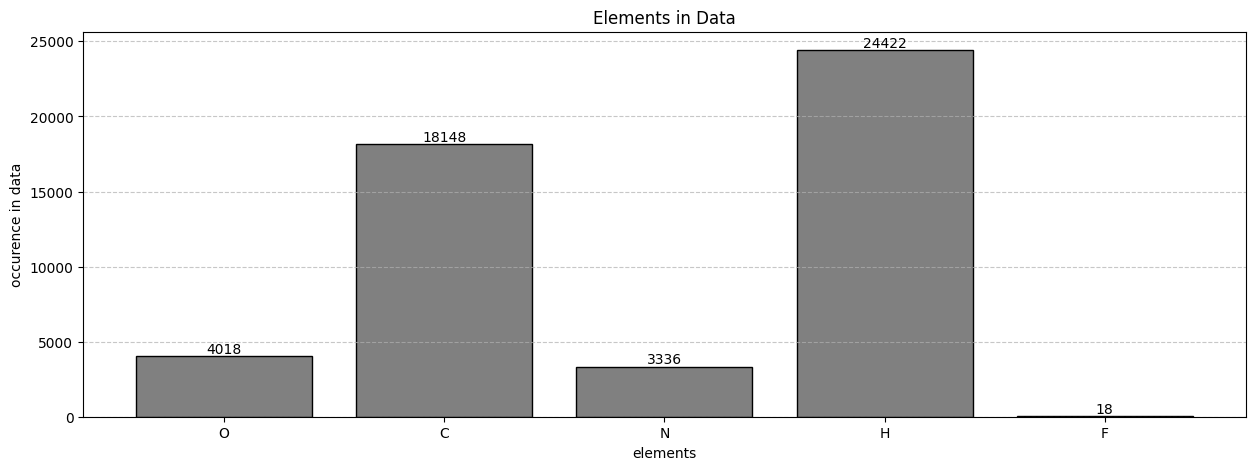

In [ ]:
atoms_x, atoms_y = compute_distribution_2d(atoms)
plot_bar(atoms_y, atoms_x, title="Elements in Data", xlabel="elements", ylabel="occurence in data")

## 4. Data splitting into training, validation, and testing set

We are splitting the dataset into training (80%), validation (10%), and test (10%) sets. The data is shuffled to ensure randomness and avoid bias. This allows us to train the model, tune parameters with the validation set, and evaluate performance with the test set.

In [ ]:
num_train = int(len(data) * 0.8)
num_val = int(len(data) * 0.1)
num_test = len(data) - num_train - num_val

shuffled_data = data[:]
random.shuffle(shuffled_data)

train_data = shuffled_data[:num_train]
val_data = shuffled_data[num_train : num_train + num_val]
test_data = shuffled_data[num_train + num_val :]

print(f"Size of the training set:\t {len(train_data)}")
print(f"Size of the validation set:\t {len(val_data)}")
print(f"Size of the testing set:\t {len(test_data)}")

Size of the training set:	 2400
Size of the validation set:	 300
Size of the testing set:	 300


## 5. Creating graphs

### 5.1 Creating a single graph from SMILES

SMILES: N#Cc1c(nc[nH]1)C#N
Atoms  in molecule: ['N', 'C', 'C', 'C', 'N', 'C', 'N', 'C', 'N', 'H', 'H']
Number of atoms: 11
Number of heavy atoms: 9
Number of hydrogen atoms: 2


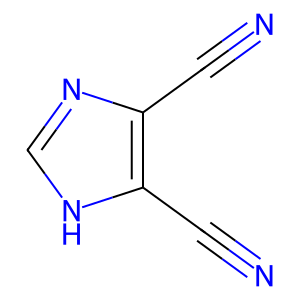

In [ ]:
sample_molecule = data[16]
print(f"SMILES: {sample_molecule['smiles']}")
print(f"Atoms  in molecule: {sample_molecule['atoms']}")
print(f"Number of atoms: {len(sample_molecule['atoms'])}")
print(f"Number of heavy atoms: {len([a for a in sample_molecule['atoms'] if a != 'H'])}")
print(f"Number of hydrogen atoms: {len([a for a in sample_molecule['atoms'] if a == 'H'])}")
sample_rdkit_molecules = Chem.MolFromSmiles(sample_molecule["smiles"])
img = Chem.Draw.MolToImage(sample_rdkit_molecules)
img

#### 5.1.1 Without hydrogen atoms

In [ ]:
smiles_graph = tgeo.utils.from_smiles(sample_molecule["smiles"], with_hydrogen=False)
smiles_graph

Data(x=[9, 9], edge_index=[2, 18], edge_attr=[18, 3], smiles='N#Cc1c(nc[nH]1)C#N')

##### Adjacency

In [ ]:
smiles_graph.edge_index.T

tensor([[0, 1],
        [1, 0],
        [1, 2],
        [2, 1],
        [2, 3],
        [2, 6],
        [3, 2],
        [3, 4],
        [3, 7],
        [4, 3],
        [4, 5],
        [5, 4],
        [5, 6],
        [6, 2],
        [6, 5],
        [7, 3],
        [7, 8],
        [8, 7]])

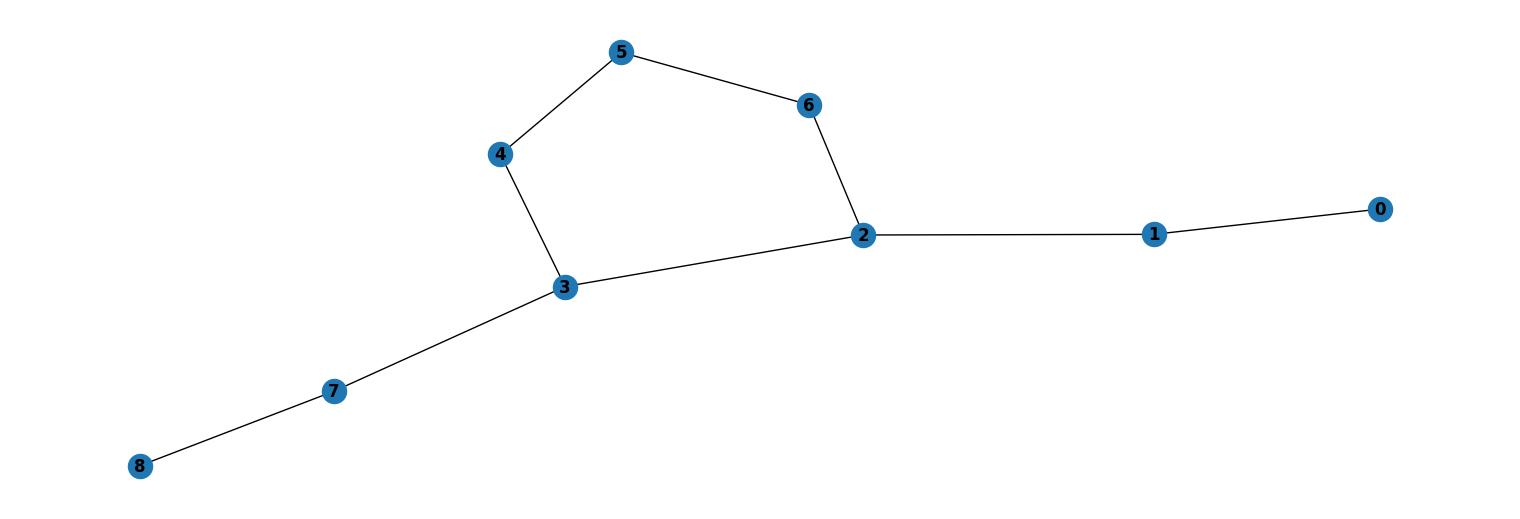

In [ ]:
g = tgeo.utils.to_networkx(smiles_graph, to_undirected=True)
nx.draw(g, with_labels=True, font_weight="bold")

##### Node Features

In [ ]:
def print_table(features, column_names):
    df = pd.DataFrame(features, columns=column_names)
    print(df)
print_table(
    smiles_graph.x,
    [
        "atomic_num",
        "chirality",
        "degree",
        "formal_charge",
        "num_hs",
        "num_radical_electrons",
        "hybridization",
        "is_aromatic",
        "is_in_ring",
    ],
)

   atomic_num  chirality  degree  formal_charge  num_hs  \
0           7          0       1              5       0   
1           6          0       2              5       0   
2           6          0       3              5       0   
3           6          0       3              5       0   
4           7          0       2              5       0   
5           6          0       3              5       1   
6           7          0       3              5       1   
7           6          0       2              5       0   
8           7          0       1              5       0   

   num_radical_electrons  hybridization  is_aromatic  is_in_ring  
0                      0              2            0           0  
1                      0              2            0           0  
2                      0              3            1           1  
3                      0              3            1           1  
4                      0              3            1           1  
5      

##### Edge Features

In [ ]:
print_table(
    smiles_graph.edge_attr,
    [
        "bond_type",
        "stereo",
        "is_conjugated",
    ],
)

    bond_type  stereo  is_conjugated
0           3       0              1
1           3       0              1
2           1       0              1
3           1       0              1
4          12       0              1
5          12       0              1
6          12       0              1
7          12       0              1
8           1       0              1
9          12       0              1
10         12       0              1
11         12       0              1
12         12       0              1
13         12       0              1
14         12       0              1
15          1       0              1
16          3       0              1
17          3       0              1


#### 5.1.2 With hydrogen atoms

In [ ]:
smiles_graph = tgeo.utils.from_smiles(sample_molecule["smiles"], with_hydrogen=True)
print(smiles_graph)

Data(x=[11, 9], edge_index=[2, 22], edge_attr=[22, 3], smiles='N#Cc1c(nc[nH]1)C#N')


##### Adjacency

In [ ]:
smiles_graph.edge_index.T

tensor([[ 0,  1],
        [ 1,  0],
        [ 1,  2],
        [ 2,  1],
        [ 2,  3],
        [ 2,  6],
        [ 3,  2],
        [ 3,  4],
        [ 3,  7],
        [ 4,  3],
        [ 4,  5],
        [ 5,  4],
        [ 5,  6],
        [ 5,  9],
        [ 6,  2],
        [ 6,  5],
        [ 6, 10],
        [ 7,  3],
        [ 7,  8],
        [ 8,  7],
        [ 9,  5],
        [10,  6]])

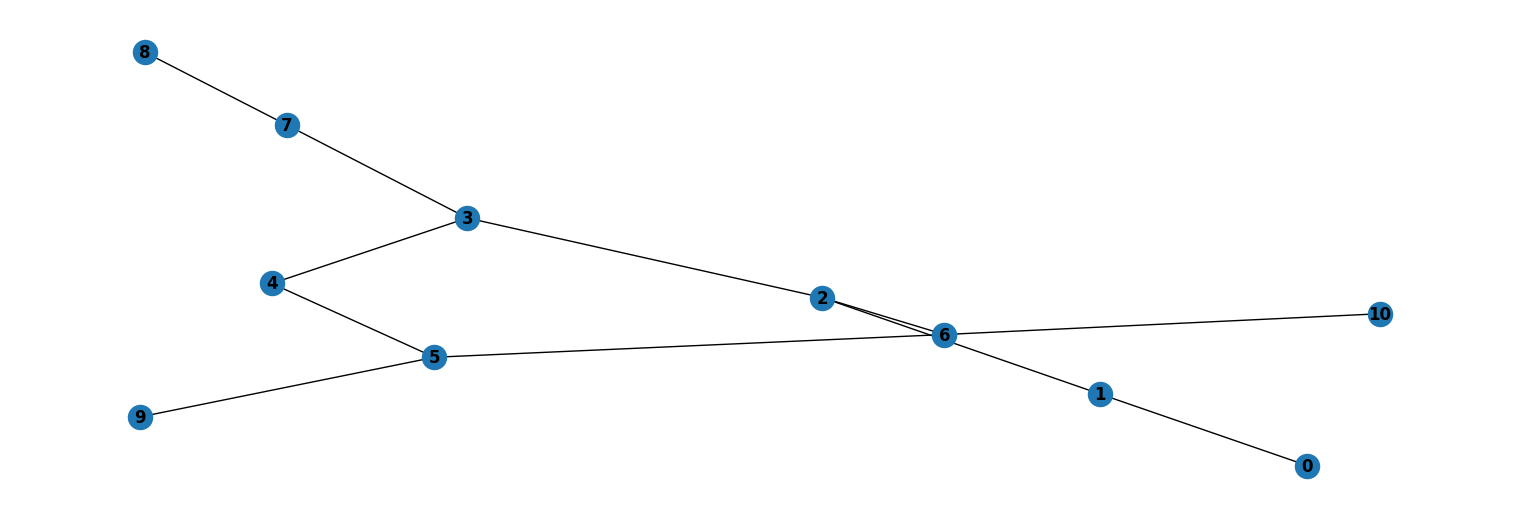

In [ ]:
g = tgeo.utils.to_networkx(smiles_graph, to_undirected=True)
nx.draw(g, with_labels=True, font_weight="bold")

##### Node features

In [ ]:
print_table(
    smiles_graph.x,
    [
        "atomic_num",
        "chirality",
        "degree",
        "formal_charge",
        "num_hs",
        "num_radical_electrons",
        "hybridization",
        "is_aromatic",
        "is_in_ring",
    ],
)

    atomic_num  chirality  degree  formal_charge  num_hs  \
0            7          0       1              5       0   
1            6          0       2              5       0   
2            6          0       3              5       0   
3            6          0       3              5       0   
4            7          0       2              5       0   
5            6          0       3              5       0   
6            7          0       3              5       0   
7            6          0       2              5       0   
8            7          0       1              5       0   
9            1          0       1              5       0   
10           1          0       1              5       0   

    num_radical_electrons  hybridization  is_aromatic  is_in_ring  
0                       0              2            0           0  
1                       0              2            0           0  
2                       0              3            1           1  
3      

##### Edge Features

In [ ]:
print_table(
    smiles_graph.edge_attr,
    [
        "bond_type",
        "stereo",
        "is_conjugated",
    ],
)

    bond_type  stereo  is_conjugated
0           3       0              1
1           3       0              1
2           1       0              1
3           1       0              1
4          12       0              1
5          12       0              1
6          12       0              1
7          12       0              1
8           1       0              1
9          12       0              1
10         12       0              1
11         12       0              1
12         12       0              1
13          1       0              0
14         12       0              1
15         12       0              1
16          1       0              0
17          1       0              1
18          3       0              1
19          3       0              1
20          1       0              0
21          1       0              0


#### 5.1.3 PROBLEM

The `from_smiles` function in `torch_geometric` is useful for generating molecular graphs, but it has a major limitation: SMILES only encodes molecular connectivity (atoms and bonds) and lacks 3D structural information such as atomic positions and bond angles.

For applications like X-ray Absorption Spectroscopy (XAS), where the exact molecular geometry significantly impacts spectral properties, relying solely on SMILES is insufficient. Instead, we have want to use ground-state optimized structures from Density Functional Theory (DFT), which provide accurate atomic coordinates.

### 5.2 Creating a single geometric graph

In [ ]:
# Plotting Function
def visualize_molecule(atom_types, coordinates, with_labels=True):
    viewer = py3Dmol.view(width=500, height=500)
    viewer.setBackgroundColor("white")
    xyz_str = f"{len(atom_types)}\n\n"
    for atom, coord in zip(atom_types, coordinates):
        xyz_str += f"{atom} {' '.join(map(str, coord))}\n"
    viewer.addModel(xyz_str, "xyz")
    viewer.setStyle({}, {"stick": {"radius": 0.1}})
    color_map = {"C": "gray", "O": "red", "H": "blue", "N": "green", "S": "yellow"}
    for atom, coord in zip(atom_types, coordinates):
        viewer.addSphere(
            {
                "center": {"x": float(coord[0]), "y": float(coord[1]), "z": float(coord[2])},
                "radius": 0.3,
                "color": color_map.get(atom, "white"),
            }
        )
        if with_labels:
            viewer.addLabel(
                atom,
                {
                    "position": {"x": float(coord[0]), "y": float(coord[1]), "z": float(coord[2])},
                    "fontSize": 10,
                    "fontColor": "white",
                    "backgroundColor": "gray",
                    "alignment": "center",
                },
            )
    viewer.zoomTo()
    return viewer.show()

In [ ]:
sample_molecule = data[16]
print(f"SMILES: {sample_molecule['smiles']}")
print(f"Atoms  in molecule: {sample_molecule['atoms']}")
print(f"Number of atoms: {len(sample_molecule['atoms'])}")
print(f"Number of heavy atoms: {len([a for a in sample_molecule['atoms'] if a != 'H'])}")
print(f"Number of hydrogen atoms: {len([a for a in sample_molecule['atoms'] if a == 'H'])}")
viewer = visualize_molecule(sample_molecule["atoms"], sample_molecule["coordinates"], with_labels=True)
viewer

SMILES: N#Cc1c(nc[nH]1)C#N
Atoms  in molecule: ['N', 'C', 'C', 'C', 'N', 'C', 'N', 'C', 'N', 'H', 'H']
Number of atoms: 11
Number of heavy atoms: 9
Number of hydrogen atoms: 2


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [ ]:
CUTOFF_RADIUS = 2.0
# CUTOFF_RADIUS = 2.5
# CUTOFF_RADIUS = 3.0
# CUTOFF_RADIUS = 5.0


# Node features
atomic_numbers = [ase.data.atomic_numbers[symbol] for symbol in sample_molecule["atoms"]]
atomic_numbers = torch.tensor(atomic_numbers, dtype=torch.long).view(-1, 1)
x = atomic_numbers

# positions -- pos
positions = sample_molecule["coordinates"]
positions = torch.tensor(positions, dtype=torch.float32)
pos = positions

# edge indices -- edge_index
edge_index = tgeo.nn.radius_graph(pos, r=CUTOFF_RADIUS, loop=False)

# edge weights (inverse distance) -- edge_weight
row, col = edge_index
dist = torch.norm(positions[row] - positions[col], dim=1)
edge_weight = 1 / dist  # invert to make shorter distances a larger weight
edge_weight = edge_weight.view(-1, 1)

# edge features -- edge_attr
edge_attr = dist.view(-1, 1)

# Create the Data object
geometric_graph = tgeo.data.Data(
    x=x,
    pos=pos,
    edge_index=edge_index,
    edge_weight=edge_weight,
    edge_attr=edge_attr,
)
print(geometric_graph)


Data(x=[11, 1], edge_index=[2, 22], edge_attr=[22, 1], pos=[11, 3], edge_weight=[22, 1])


In [ ]:
# import torch
# print(torch.__version__)


In [ ]:
# import torch
# print(torch.__version__)
# print(torch.version.cuda)


##### Adjacency

In [ ]:
geometric_graph.edge_index.T

tensor([[ 1,  0],
        [ 2,  1],
        [ 0,  1],
        [ 6,  2],
        [ 1,  2],
        [ 3,  2],
        [ 7,  3],
        [ 2,  3],
        [ 4,  3],
        [ 5,  4],
        [ 3,  4],
        [ 4,  5],
        [ 6,  5],
        [ 9,  5],
        [ 2,  6],
        [ 5,  6],
        [10,  6],
        [ 8,  7],
        [ 3,  7],
        [ 7,  8],
        [ 5,  9],
        [ 6, 10]])

In [ ]:
# Plotting function
def plot_3d_graph(data):
    if not hasattr(data, "pos"):
        raise ValueError("Data object must have a 'pos' attribute for 3D node positions.")
    G = nx.Graph()
    edge_list = data.edge_index.t().tolist()
    G.add_edges_from(edge_list)
    node_pos = {i: data.pos[i].tolist() for i in range(data.pos.shape[0])}
    fig = plt.figure(figsize=(15, 5))
    ax = fig.add_subplot(111, projection="3d")
    for edge in G.edges():
        x_vals = [node_pos[edge[0]][0], node_pos[edge[1]][0]]
        y_vals = [node_pos[edge[0]][1], node_pos[edge[1]][1]]
        z_vals = [node_pos[edge[0]][2], node_pos[edge[1]][2]]
        ax.plot(x_vals, y_vals, z_vals, "k-", alpha=0.7)
    x_nodes = [node_pos[i][0] for i in G.nodes()]
    y_nodes = [node_pos[i][1] for i in G.nodes()]
    z_nodes = [node_pos[i][2] for i in G.nodes()]
    ax.scatter(x_nodes, y_nodes, z_nodes, c="r", s=100)
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Z")
    plt.title("3D Graph Visualization")
    plt.show()

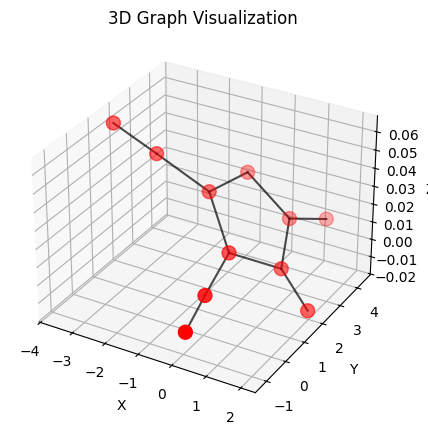

In [ ]:
plot_3d_graph(geometric_graph)

##### Node features

In [ ]:
print_table(
    geometric_graph.x,
    [
        "atomic_num",
    ],
)

    atomic_num
0            7
1            6
2            6
3            6
4            7
5            6
6            7
7            6
8            7
9            1
10           1


##### Edge features

In [ ]:
print_table(
    geometric_graph.edge_attr,
    [
        "distance",
    ],
)

    distance
0   1.158188
1   1.409605
2   1.158188
3   1.377044
4   1.409605
5   1.388988
6   1.420115
7   1.388988
8   1.371152
9   1.312804
10  1.371152
11  1.312804
12  1.359381
13  1.079453
14  1.377044
15  1.359381
16  1.008371
17  1.156685
18  1.420115
19  1.156685
20  1.079453
21  1.008371


#### 5.2.1 PROBLEM

Creating graphs solely from **DFT-optimized 3D structures**, where nodes are atomic numbers and edges are distances, has key limitations:  

1. **Loss of Bonding Information** – Distances alone don’t define molecular connectivity, making different molecules with similar geometries indistinguishable.  
2. **Lack of Chemical Context** – Bond types, hybridization, and charges are missing, which are crucial for reactivity and spectroscopy.  
3. **Graph Density Issues** – Distance-based edges introduce arbitrary cutoffs and possible long-range weak interactions.  

Ideally we would combine **bonding information** (from SMILES or molecular files) with **3D geometry** (from DFT):  
- **Nodes:** Atomic number, hybridization, partial charge, etc.
- **Edges:** Bond type (if available), distance, etc.
This would ensures the GNN captures both **chemical and spatial information**.

However for the sake of simplicity we omit this for this tutorial and continue with the simple geometric graph.

### 5.3 Creating geometric graphs for the entire dataset

We create a dataset class inhereting from the `torch_geometric.data.Dataset`. We create the geometric graph for each molecule and store it in a `data_list`.

> *`torch_geometric.data.Dataset` is a base class in the PyTorch Geometric library used for creating custom datasets. It is designed to work with graph data in PyTorch Geometric, where each graph can consist of nodes, edges, and features. When you subclass `Dataset`, you typically define how to load, preprocess, and access graph data for training. It allows for easy handling and manipulation of graph-structured data, supporting operations like batching and transforming data efficiently for neural network training.*

**Important:** We also add `"spectrum"` to the graph `torch_geometric.data.Data` objects.

In [ ]:
class Dataset(tgeo.data.Dataset):
    def __init__(self, raw_data, cutoff_radius):
        super().__init__(None, None, None)
        self.raw_data = raw_data
        self.cutoff_radius = cutoff_radius

        self.data_list = []

        self._process_data()

    def _process_data(self):
        for molecule in self.raw_data:
            # Node features
            atomic_numbers = [ase.data.atomic_numbers[symbol] for symbol in molecule["atoms"]]
            atomic_numbers = torch.tensor(atomic_numbers, dtype=torch.long).view(-1, 1)
            x = atomic_numbers

            # positions -- pos
            positions = molecule["coordinates"]
            positions = torch.tensor(positions, dtype=torch.float32)
            pos = positions

            # edge indices -- edge_index
            edge_index = tgeo.nn.radius_graph(pos, r=self.cutoff_radius, loop=False)

            # edge weights (inverse distance) -- edge_weight
            row, col = edge_index
            dist = torch.norm(positions[row] - positions[col], dim=1)
            edge_weight = 1 / dist  # invert to make shorter distances a larger weight
            edge_weight = edge_weight.view(-1, 1)

            # edge features -- edge_attr
            edge_attr = dist.view(-1, 1)

            # spectra (target) -- spectrum
            spectrum = molecule["spectrum"]
            spectrum = torch.tensor(spectrum, dtype=torch.float32).unsqueeze(0)

            # Create the Data object
            geometric_graph = tgeo.data.Data(
                x=x,
                pos=pos,
                edge_index=edge_index,
                edge_weight=edge_weight,
                edge_attr=edge_attr,
                spectrum=spectrum,
            )
            self.data_list.append(geometric_graph)
        del self.raw_data

    def len(self):
        return len(self.data_list)

    def get(self, idx):
        return self.data_list[idx]

In [ ]:
train_dataset = Dataset(raw_data=train_data, cutoff_radius=2.5)
val_dataset = Dataset(raw_data=val_data, cutoff_radius=2.5)
test_dataset = Dataset(raw_data=test_data, cutoff_radius=2.5)

print(f"Size of training dataset: {len(train_dataset)}")
print(f"Size of validation dataset: {len(val_dataset)}")
print(f"Size of testing dataset: {len(test_dataset)}")

Size of training dataset: 2400
Size of validation dataset: 300
Size of testing dataset: 300


> *The `torch_geometric.loader.DataLoader` in PyTorch Geometric is used to load and batch graph data for training. It handles batching of graphs, shuffling, and collating data into a format that can be used by models. It works similarly to PyTorch's `DataLoader` but is specifically for graph structures.*

In [ ]:
dataloader = tgeo.loader.DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True,
    num_workers=0,
)

In [ ]:
val_dataloader = tgeo.loader.DataLoader(
    val_dataset,
    batch_size=128,
    shuffle=False,
    num_workers=0,
)

In [ ]:
test_dataloader = tgeo.loader.DataLoader(
    test_dataset,
    batch_size=128,
    shuffle=False,
    num_workers=0,
)

## 6. A simple Graph Neural Network

`simpleGNN` is a simple modular graph neural network with:
- Atom embeddings for node initialization.
- Residual layers to improve gradient flow.
- Interaction blocks for graph convolution.
- Global add pooling for graph-level aggregation.
- Final dense layers for output prediction.

It supports flexible architecture that can be custumized as follows:
- `num_interactions`: Defines the number of interaction layers.
- `num_res`: Defines the number of residual layers per interaction block.
- `num_hidden`: Defines the hidden node feature size.
- `num_targets`: Defines the final target vector size.
- `num_final`: Defines the number of final dense layers.

In [ ]:
# Add the path to your GNN folder
import sys
sys.path.append('/content/drive/My Drive/Hendrick/')

# Import the simpleGNN class
#from gnn import simpleGNN
from GNN.gnn import simpleGNN

model_size = "big"  # 'big', 'medium', or 'small'

# Configurations
if model_size == "big":  # Large model:
    num_interactions = 3
    num_res = 2
    num_hidden = 50
    num_final = 4
elif model_size == "medium":  # Medium model:
    num_interactions = 2
    num_res = 1
    num_hidden = 30
    num_final = 3
elif model_size == "small":  # Small model:
    num_interactions = 1
    num_res = 1
    num_hidden = 10
    num_final = 1
else:
    raise ValueError(f"Model size {model_size} not recognized!")

gnn = simpleGNN(
    num_interactions=num_interactions,
    num_res=num_res,
    num_hidden=num_hidden,
    num_targets=100,
    num_final=num_final,
    conv_layer_type='gcn'
)

### 6.1 Architecture

In [ ]:
print(gnn)

simpleGNN(
  (atom_emb): AtomEmbedding(
    (embeddings): Embedding(10, 50)
  )
  (res_layers): ModuleList(
    (0-3): 4 x ResidualLayer(
      (dense_mlp): Sequential(
        (0): Dense(
          (linear): Linear(in_features=50, out_features=50, bias=False)
          (_activation): ScaledSiLU(
            (_activation): SiLU()
          )
        )
        (1): Dense(
          (linear): Linear(in_features=50, out_features=50, bias=False)
          (_activation): ScaledSiLU(
            (_activation): SiLU()
          )
        )
      )
    )
  )
  (interaction_blocks): ModuleList(
    (0-2): 3 x GCNInteraction(
      (conv): GCNConv(50, 50)
    )
  )
  (dense_layers): ModuleList(
    (0-2): 3 x Dense(
      (linear): Linear(in_features=50, out_features=50, bias=False)
      (_activation): ScaledSiLU(
        (_activation): SiLU()
      )
    )
    (3): Dense(
      (linear): Linear(in_features=50, out_features=100, bias=False)
      (_activation): Identity()
    )
  )
)


### 6.2 Trainable parameters

In [ ]:
num_params = sum(p.numel() for p in gnn.parameters() if p.requires_grad)

print(f"Number of trainable parameters: {num_params}")

Number of trainable parameters: 40650


## 7. Training

### 7.1 Optimizer (Adam)

In [ ]:
LEARNING_RATE = 0.001
optimizer = torch.optim.Adam(gnn.parameters(), lr=LEARNING_RATE)

### 7.2 Loss function (Criterion)

In [ ]:
class MSELoss(torch.nn.Module):
    def forward(self, y_pred, y_true):
        return F.mse_loss(y_pred, y_true)


class MAELoss(torch.nn.Module):
    def forward(self, y_pred, y_true):
        return F.l1_loss(y_pred, y_true)


class HuberLoss(torch.nn.Module):
    def __init__(self, delta=1.0):
        """
        Huber loss function.
        Args:
            delta (float): Threshold where loss transitions from quadratic (MSE-like) to linear (MAE-like).
        """
        super(HuberLoss, self).__init__()
        self.delta = delta

    def forward(self, y_pred, y_true):
        error = y_pred - y_true
        abs_error = torch.abs(error)

        quadratic = 0.5 * error**2
        linear = self.delta * (abs_error - 0.5 * self.delta)

        loss = torch.where(abs_error < self.delta, quadratic, linear)
        return torch.mean(loss)


class Combined(torch.nn.Module):
    def __init__(self):
        super().__init__()

        self.losses = []
        self.coeff = []

        self._create_losses()

    def _create_losses(self):
        self.losses.append(MSELoss())
        self.coeff.append(0.5)
        self.losses.append(MAELoss())
        self.coeff.append(0.5)

    def forward(self, y_pred, y_true):
        final_loss = 0.0
        for loss, c in zip(self.losses, self.coeff):
            final_loss += c * loss(y_pred, y_true)
        return final_loss


loss_fn = HuberLoss()

### 7.3 Spectral scaling

One challenge we need to address before predicting X-ray Absorption Spectroscopy (XAS) is the fact that our spectra have intensity values ranging from 0 to 3000. This range is suboptimal for training neural networks, as it is typically more effective to work with normalized values, such as those between -1 and 1 or -2 and 2. To overcome this, we scale the spectra to a more suitable range. Additionally, we ensure that the inverse scaling is unique, which is crucial for maintaining the integrity of the data during the model's prediction phase.

In [ ]:
from GNN.utils.spectral_scaling import SpectraScaler

spectral_scaler = SpectraScaler("zscore")
all_train_spectra = np.zeros((len(train_data), len(train_data[0]["spectrum"])))
for i, molecule in enumerate(train_data):
    all_train_spectra[i] = molecule["spectrum"]
spectral_scaler.fit(all_train_spectra)

# saving the spectral scaler
with open("/content/drive/My Drive/Hendrick/out/scaler.pkl", "wb") as f:
    pickle.dump(spectral_scaler, f)

In [ ]:
# Plotting function
def plot_3_arrays(array1, array2, array3, title1, title2, title3, x_label, y_label):
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    for ax, array, title in zip(axes, [array1, array2, array3], [title1, title2, title3]):
        ax.plot(array)
        ax.set_title(title, fontsize=14)
        ax.set_xlabel(x_label)
        ax.set_ylabel(y_label)
    plt.tight_layout()
    plt.show()

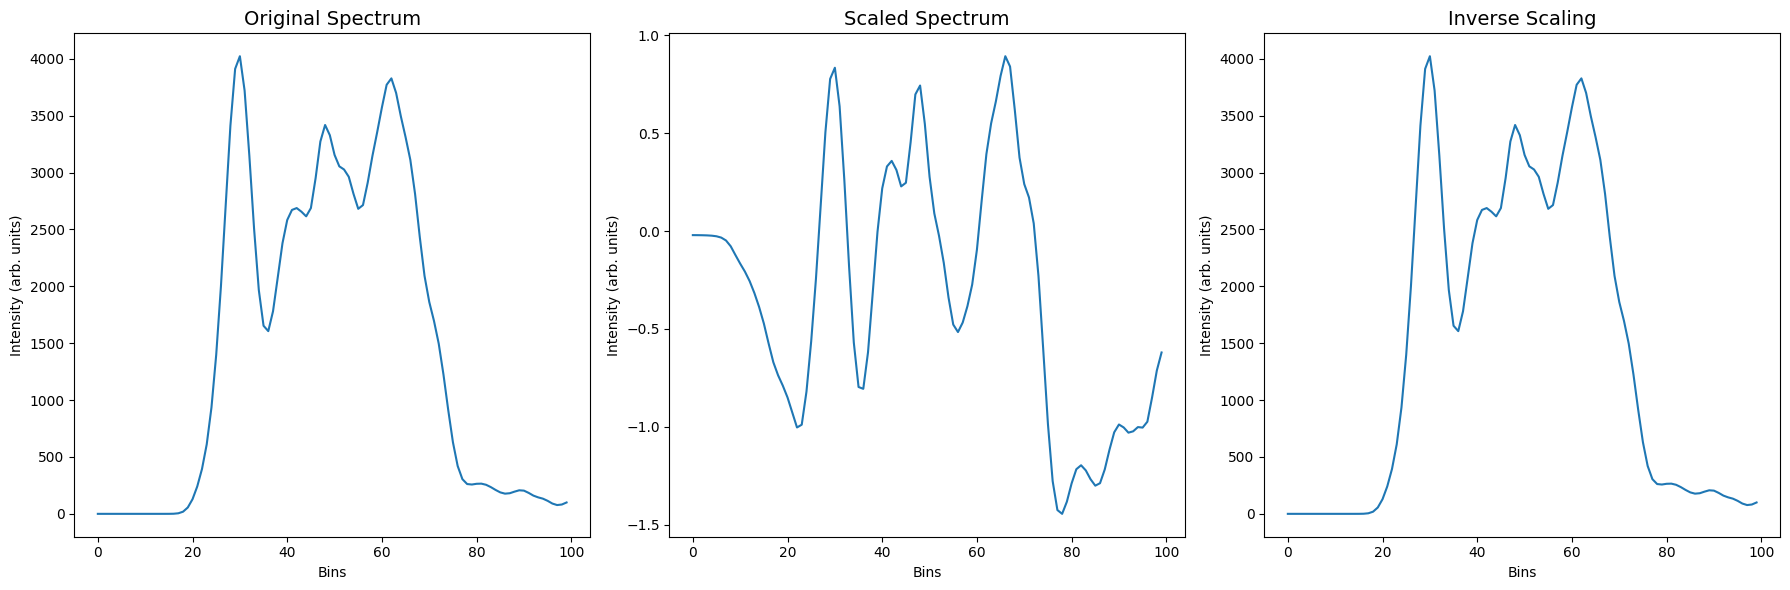

In [ ]:
sample_spectrum = train_data[0]["spectrum"]
sample_spectrum_scaled = spectral_scaler(sample_spectrum.reshape(1, -1))
sample_spectrum_inverse = spectral_scaler(sample_spectrum_scaled, inverse=True)

sample_spectrum_scaled = sample_spectrum_scaled.flatten()
sample_spectrum_inverse = sample_spectrum_inverse.flatten()

plot_3_arrays(
    sample_spectrum,
    sample_spectrum_scaled,
    sample_spectrum_inverse,
    "Original Spectrum",
    "Scaled Spectrum",
    "Inverse Scaling",
    x_label="Bins",
    y_label="Intensity (arb. units)",
)

### 7.4 Training loop

In [ ]:
def plot_losses(arrays, titles, x_label, y_label):
    fig, ax = plt.subplots(figsize=(10, 6))

    x_values = np.arange(len(arrays[1]))
    valid_x = [x for x, val in zip(x_values, arrays[1]) if not np.isnan(val)]
    valid_y = [val for val in arrays[1] if not np.isnan(val)]

    ax.plot(arrays[0], label=titles[0], linestyle="-", marker="")
    ax.plot(valid_x, valid_y, label=titles[1], linestyle="-", marker="")

    ax.set_title("Losses", fontsize=14)
    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)
    ax.legend()
    plt.tight_layout()
    plt.show()

In [ ]:
def validate():
    gnn.eval()
    val_loss = 0.0

    with torch.no_grad():
        for batch in val_dataloader:

            predictions = gnn(
                x=batch.x,
                edge_index=batch.edge_index,
                edge_weight=batch.edge_weight,
                batch=batch.batch,
            )

            gt_spectra_scaled = spectral_scaler(batch.spectrum)

            loss = loss_fn(predictions, gt_spectra_scaled)

            val_loss += loss.item()

    return val_loss / len(val_dataloader)

In [ ]:
NUM_EPOCHS = 600
EPOCH_LR_DECAY = [300, 500]
LR_DECAY = 0.1
PRINT_INTERVAL = 50
VAL_INTERVAL = 50
CHECKPOINT_INTERVAL = 50

best_val_loss = float("inf")

gnn.train()

epoch_losses = []
val_losses = []
checkpoint_id = 0

for epoch in range(NUM_EPOCHS):
    epoch_loss = 0.0

    for batch in dataloader:

        optimizer.zero_grad()

        predictions = gnn(
            x=batch.x,
            edge_index=batch.edge_index,
            edge_weight=batch.edge_weight,
            batch=batch.batch,
        )

        with torch.no_grad():
            gt_spectra_scaled = spectral_scaler(batch.spectrum)

        loss = loss_fn(predictions, gt_spectra_scaled)

        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    epoch_loss = epoch_loss / len(dataloader)
    epoch_losses.append(epoch_loss)
    if epoch % PRINT_INTERVAL == 0:
        print(f"Epoch loss: {epoch_loss}")

    if epoch % VAL_INTERVAL == 0:
        val_loss = validate()
        val_losses.append(val_loss)
        print(f"> Validation loss: {val_loss}")
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            print(f"> Save best model!")
            torch.save(gnn, "/content/drive/My Drive/Hendrick/out/gnn_best.pth")
    else:
        val_losses.append(float("nan"))

    if epoch % CHECKPOINT_INTERVAL == 0:
        torch.save(gnn, f"/content/drive/My Drive/Hendrick/out/gnn_checkpoint_{checkpoint_id}.pth")
        checkpoint_id += 1

    if epoch in EPOCH_LR_DECAY:
        for param_group in optimizer.param_groups:
            param_group["lr"] *= LR_DECAY
        current_lr = optimizer.param_groups[0]["lr"]
        print(f">>> Changed learning rate: {current_lr}")


# saving trained model
torch.save(gnn, "/content/drive/My Drive/Hendrick/out/gnn_trained.pth")

Epoch loss: 0.3512115149121535
> Validation loss: 0.3256104489167531
> Save best model!
Epoch loss: 0.21324648119901357
> Validation loss: 0.235691969593366
> Save best model!
Epoch loss: 0.17043711401914297
> Validation loss: 0.21199956039587656
> Save best model!
Epoch loss: 0.14240529741111554
> Validation loss: 0.23389621078968048
Epoch loss: 0.12470185246906783
> Validation loss: 0.24522454043229422
Epoch loss: 0.11247564224820387
> Validation loss: 0.2482227236032486
Epoch loss: 0.10440667757862493
> Validation loss: 0.2510639826456706
>>> Changed learning rate: 0.0001
Epoch loss: 0.09605391323566437
> Validation loss: 0.25797076523303986
Epoch loss: 0.09480139926860207
> Validation loss: 0.26119573414325714
Epoch loss: 0.09365828100003694
> Validation loss: 0.26478908956050873
Epoch loss: 0.09211691939517071
> Validation loss: 0.2679366171360016
>>> Changed learning rate: 1e-05
Epoch loss: 0.09149881805244245
> Validation loss: 0.2689819286266963


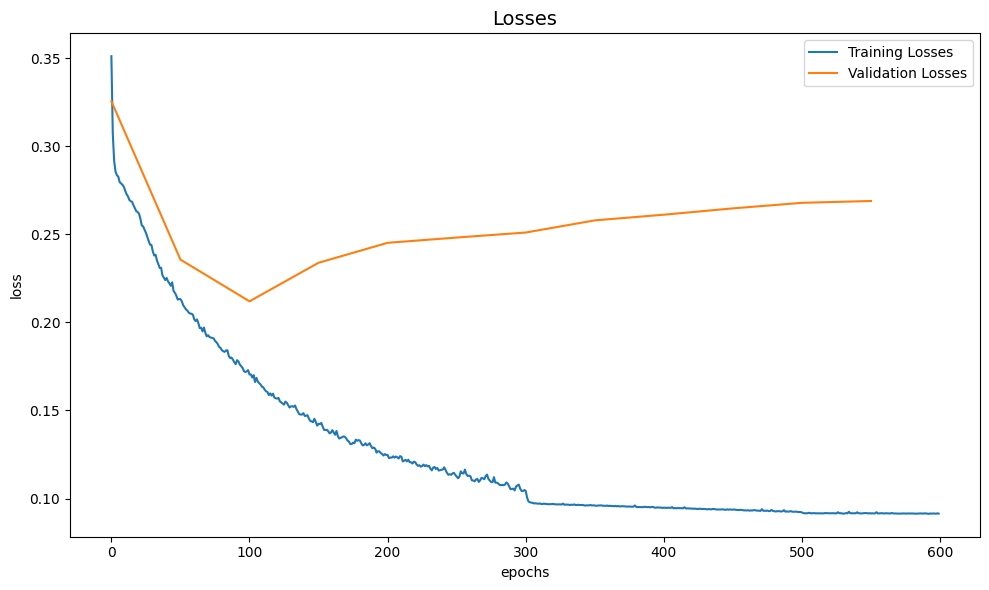

In [ ]:
plot_losses([epoch_losses, val_losses], ["Training Losses", "Validation Losses"], x_label="epochs", y_label="loss")

## 8. Testing

In [ ]:
def plot_4_arrays(arrays, titles, x_label, y_label):
    fig, axes = plt.subplots(2, 1, figsize=(10, 10))
    axes[0].plot(arrays[0], label=titles[0])
    axes[0].plot(arrays[1], label=titles[1])
    axes[0].set_title(f"{titles[0]} & {titles[1]}", fontsize=14)
    axes[0].set_xlabel(x_label)
    axes[0].set_ylabel(y_label)
    axes[0].legend()
    axes[1].plot(arrays[2], label=titles[2])
    axes[1].plot(arrays[3], label=titles[3])
    axes[1].set_title(f"{titles[2]} & {titles[3]}", fontsize=14)
    axes[1].set_xlabel(x_label)
    axes[1].set_ylabel(y_label)
    axes[1].legend()
    plt.tight_layout()
    plt.show()

### 8.1 Loading the trained model and spectral scaler

In [ ]:
gnn = torch.load("/content/drive/My Drive/Hendrick/out/gnn_best.pth", weights_only=False) # set weights_only=False
with open("/content/drive/My Drive/Hendrick/out/scaler.pkl", "rb") as f:
    spectral_scaler = pickle.load(f)

### 8.2 Testing the training dataset

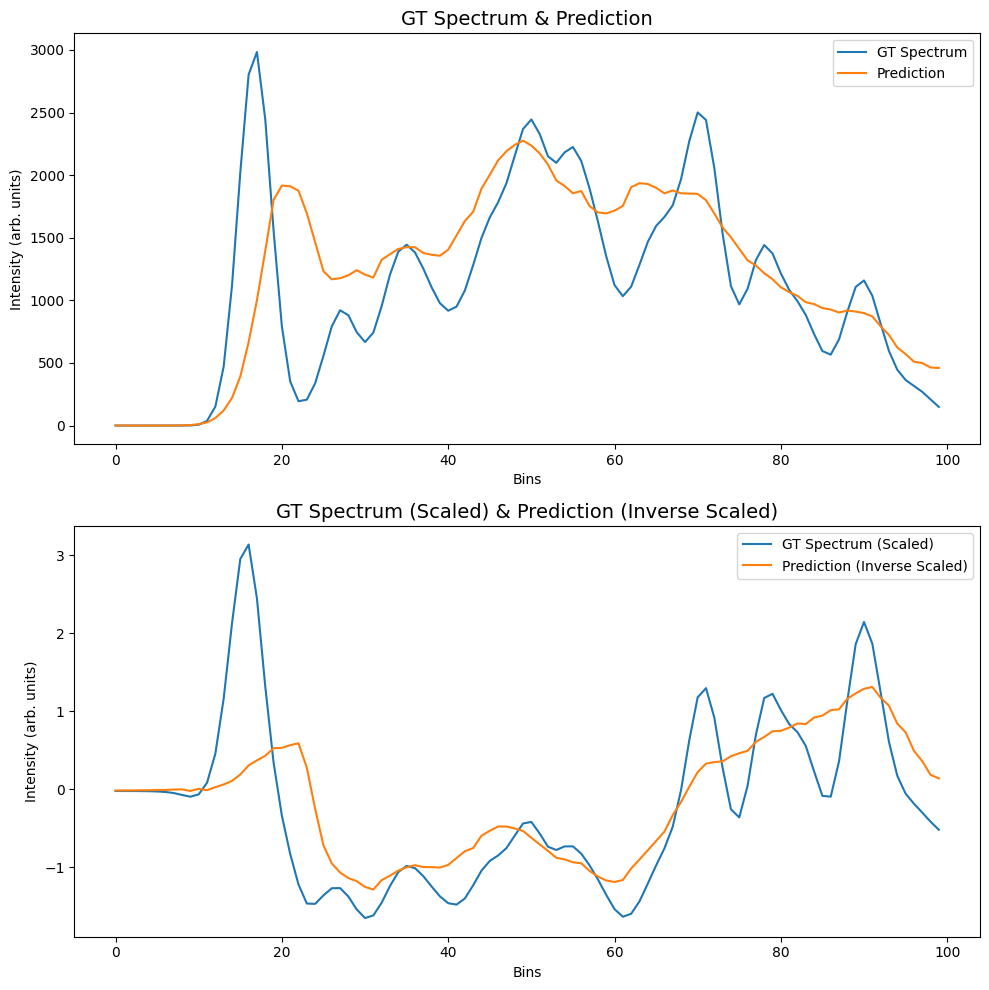

In [ ]:
gnn.eval()

# uses the training dataloader from above
with torch.no_grad():
    for batch in dataloader:
        predictions = gnn(
            x=batch.x,
            edge_index=batch.edge_index,
            edge_weight=batch.edge_weight,
            batch=batch.batch,
        )

        gt_spectra = batch.spectrum
        gt_spectra_scaled = spectral_scaler(gt_spectra)

        prediction_scaled_inv = spectral_scaler(predictions, inverse=True)

        break

single_gt_spectra = gt_spectra[0]
single_gt_spectra_scaled = gt_spectra_scaled[0]
single_prediction_scaled_inv = prediction_scaled_inv[0]
single_prediction = predictions[0]

arrays = [single_gt_spectra, single_prediction_scaled_inv, single_gt_spectra_scaled, single_prediction]
titles = ["GT Spectrum", "Prediction", "GT Spectrum (Scaled)", "Prediction (Inverse Scaled)"]

plot_4_arrays(arrays, titles, "Bins", "Intensity (arb. units)")

### 8.3 Testing the testing dataset

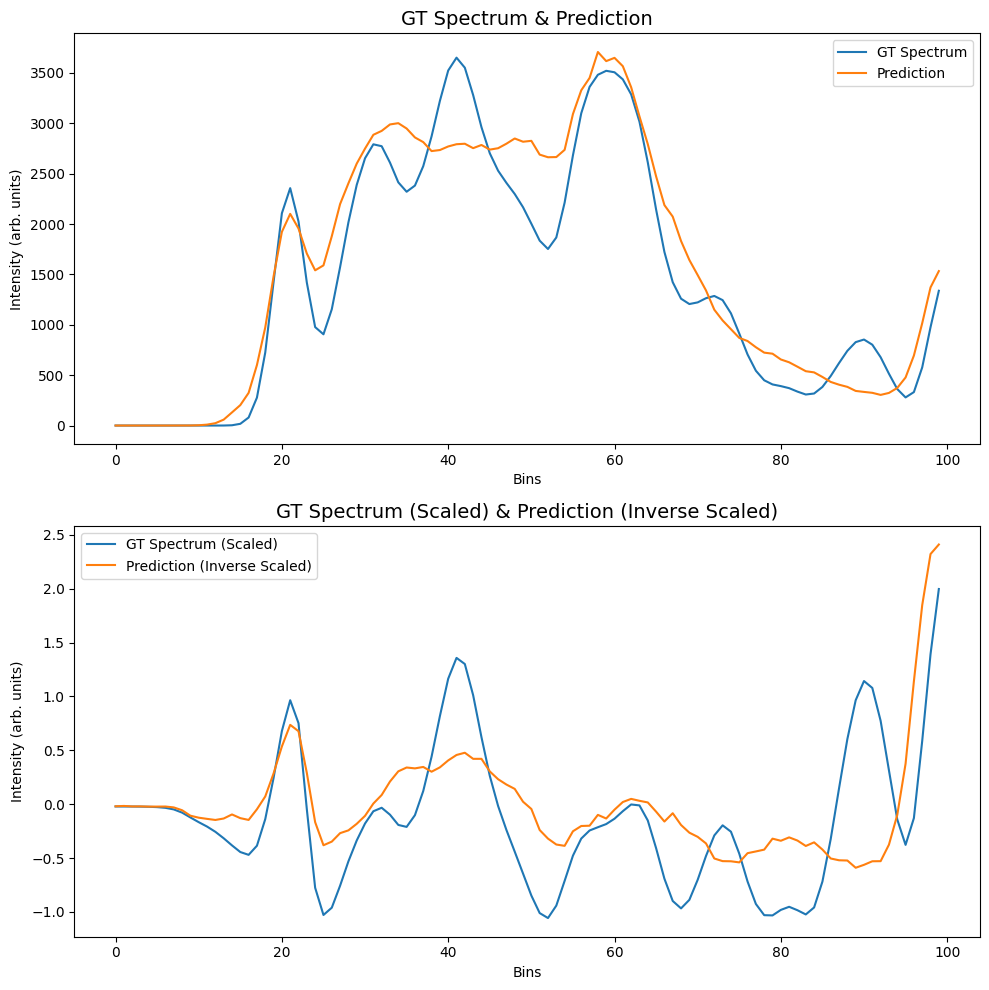

In [ ]:
gnn.eval()

with torch.no_grad():
    for batch in test_dataloader:
        predictions = gnn(
            x=batch.x,
            edge_index=batch.edge_index,
            edge_weight=batch.edge_weight,
            batch=batch.batch,
        )

        gt_spectra = batch.spectrum
        gt_spectra_scaled = spectral_scaler(gt_spectra)

        prediction_scaled_inv = spectral_scaler(predictions, inverse=True)

        break

single_gt_spectra = gt_spectra[0]
single_gt_spectra_scaled = gt_spectra_scaled[0]
single_prediction_scaled_inv = prediction_scaled_inv[0]
single_prediction = predictions[0]

arrays = [single_gt_spectra, single_prediction_scaled_inv, single_gt_spectra_scaled, single_prediction]
titles = ["GT Spectrum", "Prediction", "GT Spectrum (Scaled)", "Prediction (Inverse Scaled)"]

plot_4_arrays(arrays, titles, "Bins", "Intensity (arb. units)")

### 8.4 Loss over the entire testing dataset

In [ ]:
gnn.eval()
test_loss = 0.0

with torch.no_grad():
    for batch in test_dataloader:

        predictions = gnn(
            x=batch.x,
            edge_index=batch.edge_index,
            edge_weight=batch.edge_weight,
            batch=batch.batch,
        )

        predictions_scaled_inv = spectral_scaler(predictions, inverse=True)

        loss = loss_fn(predictions_scaled_inv, batch.spectrum)

        test_loss += loss.item()

test_loss /= len(test_dataloader)

print(f"Loss for the entire testing dataset: {test_loss}")

Loss for the entire testing dataset: 403.0547688802083
